In [326]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic_2d
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

import stream_dataset as sd
import GC
import agama_stream as ags

In [202]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/agama_stream.py'>

**download and select isochrones**

In [218]:
# download isochrone

feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = 10.0**feh_list*0.0152

# download gaia isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_gaia/feh%g.csv'%feh_list[i])

# download cfht isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='megacam_wircam') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_cfht/feh%g.csv'%feh_list[i])

In [60]:
# load isochrone

iso_gaia_list = []
for i in range(len(feh_list)):
    iso_gaia_list.append(pd.read_csv('../data/iso_gaia/feh%g.csv'%feh_list[i]))
    
iso_cfht_list = []
for i in range(len(feh_list)):
    iso_cfht_list.append(pd.read_csv('../data/iso_cfht/feh%g.csv'%feh_list[i]))

In [259]:
# select isochrone

def select_iso(color, mag, iso_list, color1_key, color2_key, mag_key):
    
    comp = np.inf
    idx = np.nan
    
    for j in range(len(iso_list)):
        iso = iso_list[j]
        iso_color1 = iso[color1_key]
        iso_color2 = iso[color2_key]
        iso_mag = iso[mag_key]
        
        mask = iso['label'] <= 3
        iso_color = iso_color1[mask][::-1]-iso_color2[mask][::-1]
        iso_mag = iso_mag[mask][::-1]

        dcolor = color - np.interp(mag, iso_mag, iso_color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j

    return idx

def calc_mass(mag, iso, mag_key):
    iso_mag = iso[mag_key]
    iso_Mini = iso['Mini']
    
    mask = iso['label'] <= 3
    iso_mag = iso_mag[mask][::-1]
    iso_Mini = iso_Mini[mask][::-1]
    return np.interp(mag, iso_mag, iso_Mini)

**name converter**

In [4]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

**detect segments from streams**

In [5]:
def detect_segs(stream, width=None, gap_angle=10, percentiles=[10,90], min_count=10):
    angle_tid = stream.prog['rt'] / stream.prog['Rsun'] * 1e-3 * 180 / np.pi
    if width is None:
        width = np.sqrt(np.mean(stream.phi2hat**2))
    segs = []
    if stream.prog_phi2hat < width and stream.prog_phi2hat > -width:
        maskl = (stream.phi1 < stream.prog_phi1 - angle_tid) 
        maskr = (stream.phi1 > stream.prog_phi1 + angle_tid)
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskl]), gap_angle, percentiles, min_count))
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskr]), gap_angle, percentiles, min_count))
    else:
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1), gap_angle, percentiles, min_count))
    return segs

def detect_gaps_in_arms(phi1_arm, gap_angle=10, percentiles=[10,90], min_count=10):
    cuts = [-np.inf]
    for i in range(len(phi1_arm)-1):
        if phi1_arm[i+1] - phi1_arm[i] >= gap_angle:
            cuts.append((phi1_arm[i+1] + phi1_arm[i])/2)
    cuts.append(np.inf)
    
    segs = []
    for i in range(len(cuts)-1):
        mask = (phi1_arm > cuts[i]) & (phi1_arm <= cuts[i+1])
        seg = np.percentile(phi1_arm[mask], percentiles)
        segs.append(seg)
        if len(phi1_arm[mask]) < min_count:
            continue
    return segs

**calculate Gaussian width for segments**

In [6]:
def calc_selection_function(stream, segs):
    gaussian_widths = []
    for seg in segs:
        mask = (stream.phi1 > seg[0]) & (stream.phi1 <= seg[1])
        gaussian_widths.append(calc_gaussian_width_seg(stream.phi2hat[mask]))
    return gaussian_widths

def calc_gaussian_width_seg(seg_phi2hat):
    return np.sqrt(np.mean(seg_phi2hat**2))

**IMF**

In [92]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)

kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    pass

### Load stream data

**load GC data**

In [470]:
# load GC info as pandas dataframe
gc = GC.load_GC()

# use Koposov+17 for Pal 5
gc.at['Pal_5', 'RA'] = 229
gc.at['Pal_5', 'DEC'] = -0.111
gc.at['Pal_5', 'Rsun'] = 23.2 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'R_Sun'] = 23.2 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'mu_alpha'] = -2.23
gc.at['Pal_5', 'mu_delta'] = -2.22
gc.at['Pal_5', '<RV>'] = -59.0 # hilker: 58.51, Koposov: 57.4

**load Ibata+24**

In [282]:
G_limit = 19

In [235]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['Pal_5'] # test case
gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:02,  2.15s/it]


**load Ibata+19**

In [283]:
r_limit = 22

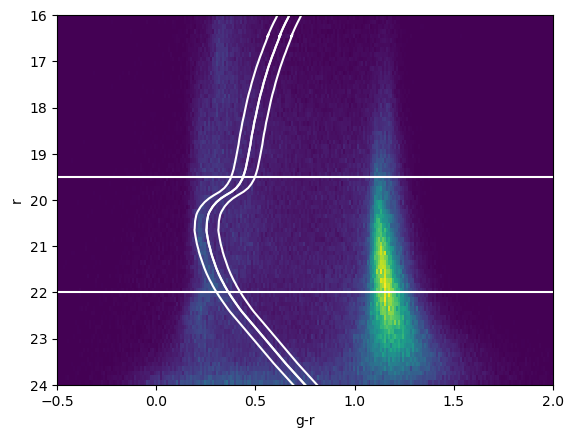

In [471]:
# load Ibata+19
hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
data = hdul[1].data
hdul.close()

plt.hist2d(data['g0mag']-data['r0mag'], data['r0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)))#, norm=mpl.colors.LogNorm())

# apply CMD mask
iso = iso_cfht_list[2]
mask = iso['label'] <= 3
x = iso["g'mag"][mask]-iso["r'mag"][mask]
y = iso["r'mag"][mask]+16.6
interp = interp1d(y, x, bounds_error=False, fill_value=999)

plt.plot(x+0.03, y, c='w')
plt.plot(x-0.03, y, c='w')
plt.hlines([19.5, 22], -0.5, 2.0, color='w')

color_width = 0.05

mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])-color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

ds_i19 = {}
ds_i19['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

# Now, the background
mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])+color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+3*color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

plt.plot(x+0.03, y, c='w')
plt.plot(x+0.09, y, c='w')

ds_i19_bg = {}
ds_i19_bg['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

plt.ylim(24,16)
plt.xlabel('g-r')
plt.ylabel('r')
plt.show()

In [473]:
ds_i19['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)
ds_i19_bg['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19_bg['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [474]:
ds_i19['Pal_5'].apply_mask((ds_i19['Pal_5'].phi1<14) & (ds_i19['Pal_5'].phi1>-14))
ds_i19_bg['Pal_5'].apply_mask((ds_i19_bg['Pal_5'].phi1<14) & (ds_i19_bg['Pal_5'].phi1>-14))

(-2.0, 2.0)

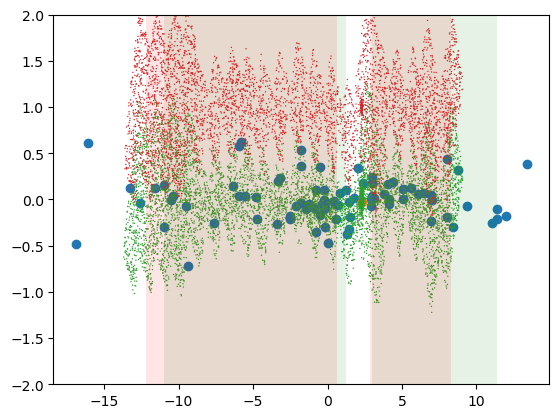

In [293]:
plt.scatter(ds_i24['Pal_5'].phi1, ds_i24['Pal_5'].phi2hat)
plt.scatter(ds_i24['Pal_5'].prog_phi1, ds_i24['Pal_5'].prog_phi2hat)
segs = detect_segs(ds_i24['Pal_5'])
for seg in segs:
    plt.fill_betweenx([-2,2], [seg[0],seg[0]], [seg[1],seg[1]], fc='g', ec='none', alpha=0.1)

plt.scatter(ds_i19['Pal_5'].phi1, ds_i19['Pal_5'].phi2hat, s=1, ec='none')
plt.scatter(ds_i19_bg['Pal_5'].phi1, ds_i19_bg['Pal_5'].phi2hat+1, s=1, ec='none')
segs = detect_segs(ds_i19['Pal_5'])
for seg in segs:
    plt.fill_betweenx([-2,2], [seg[0],seg[0]], [seg[1],seg[1]], fc='r', ec='none', alpha=0.1)

# plt.xlim(-15,15)
plt.ylim(-2,2)

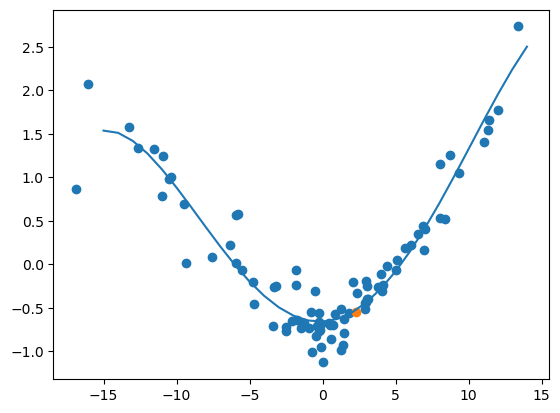

In [14]:
plt.scatter(ds_i24['Pal_5'].phi1, ds_i24['Pal_5'].phi2)
plt.scatter(ds_i24['Pal_5'].prog_phi1, ds_i24['Pal_5'].prog_phi2)

x = np.arange(-15,15,1)
plt.plot(x, ds_i24['Pal_5'].fit_poly(x))

In [15]:
# load Ibata+24
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['NGC_5139'] # test case
gc_stream_ids = np.array([54], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:04,  4.27s/it]


In [236]:
# generate mock stream

pot_agama = agama.Potential("../data/MWPotential2014.ini")

t_tot = 4000 * u.Myr
dt = 1 * u.Myr
key = 'Pal_5'
stream = ds_i24[key]

gc_mass = 10**stream.prog['logm']
c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
gc_w0 = gd.PhaseSpacePosition(c_gc)
gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
    ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
        pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot)

mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
    v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())

mockstream = sd.StreamDataset('mock', None, 
    mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
    None, 
    mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
    None, None, 
    mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
    None, None, None, stream.prog)

mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
mockstream.construct_polynomial_coord(p=stream.p, deg=4)

7998 orbits complete (4696 orbits/s)


mass of a segment = 13550.1 Msun
mass of a segment = 7564.89 Msun
total mass from Gaia = 21115 Msun


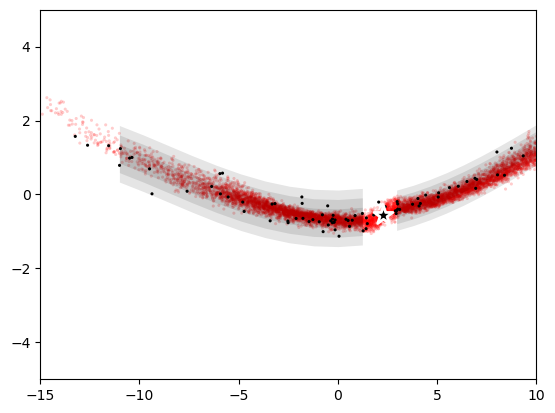

In [303]:
key = 'Pal_5'
mass_func = kroupa
yaxis = 'phi2'

stream = ds_i24[key]

# plot mock stars and prog GC
x = mockstream.phi1
x_prog = mockstream.prog_phi1
if yaxis == 'phi2hat':
    y = mockstream.phi2hat
elif yaxis == 'phi2':
    y = mockstream.phi2
else:
    raise AttributeError
plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
plt.scatter(x, y, s=5, ec='none', fc='k')
plt.scatter(x_prog, y_prog, s=200, ec='w', fc='k', marker='*', lw=2)

# detect segments
segs = detect_segs(stream)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
dist_mod = 5*(np.log10(dist)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_gaia_list, 'G_BPmag', 'G_RPmag', 'Gmag')

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
mass_min = calc_mass(G_limit - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
mass_max = np.max(iso_gaia_list[iso_idx]['Mini'][iso_gaia_list[iso_idx]['label']<=3])

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)

# print('total mass = %g Msun'%np.sum(masses*weights))

mtot = 0
# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):
    # plot the Gaussian width
    for factor in [1,2,3]:
        if yaxis == 'phi2hat':
            x = seg
            y = np.zeros_like(seg)
        elif yaxis == 'phi2':
            x = np.linspace(seg[0], seg[1], 11)
            y = stream.fit_poly(x)
        plt.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
        
    print('mass of a segment = %g Msun'%np.sum(masses[mask]*weights[mask]))
    mtot += np.sum(masses[mask]*weights[mask])

print('total mass from Gaia = %g Msun'%mtot)

plt.xlim(-15,10)
plt.ylim(-5,5)

plt.show()

### Estimate the mass of Pal 5 from CFHT

**Method 1: cut a different region in CMD as background**

**Disliked by Eric**

mass of a segment = 16241 Msun
mass of a segment = 8000.26 Msun
total mass from CFHT = 24241.3 Msun


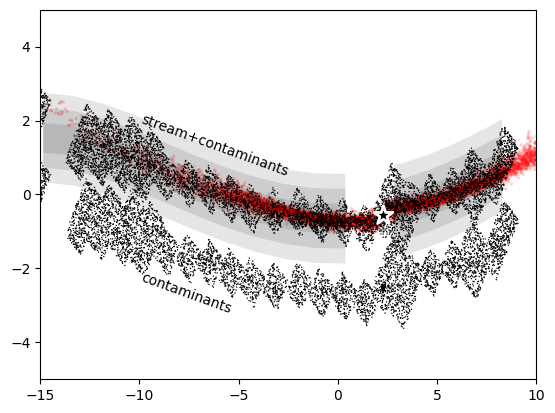

In [434]:
key = 'Pal_5'
mass_func = kroupa
yaxis = 'phi2'

stream = ds_i19[key]
stream_bg = ds_i19_bg[key]

# plot mock stars and prog GC
x = mockstream.phi1
x_prog = mockstream.prog_phi1
if yaxis == 'phi2hat':
    y = mockstream.phi2hat
elif yaxis == 'phi2':
    y = mockstream.phi2
else:
    raise AttributeError
plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
plt.scatter(x, y, s=1, ec='none', fc='k')
plt.scatter(x_bg, y_bg-2, s=1, ec='none', fc='k')
plt.scatter(x_prog, y_prog, s=200, ec='w', fc='k', marker='*', lw=2)

# detect segments
segs = detect_segs(stream)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
dist_bg = np.full_like(stream_bg.phi1, fill_value=stream_bg.c_prog.distance.to_value('kpc'))
dist_mod = 5*(np.log10(dist)+2)
dist_bg_mod = 5*(np.log10(dist_bg)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
masses_bg = calc_mass(stream_bg.mag - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min_bg = calc_mass(r_limit - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)
weights_bg = mass_func(0, mass_max) / mass_func(mass_min_bg, mass_max)

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):
    # plot the Gaussian width
    for factor in [1,2,3]:
        if yaxis == 'phi2hat':
            x = seg
            y = np.zeros_like(seg)
        elif yaxis == 'phi2':
            x = np.linspace(seg[0], seg[1], 11)
            y = stream.fit_poly(x)
        plt.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
    mask_bg = (stream_bg.phi1>seg[0]) & (stream_bg.phi1<seg[1])
        
    print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    # print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])))
    # print('mass of a segment = %g Msun'%(np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    mtot += np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])

print('total mass from CFHT = %g Msun'%mtot)

plt.xlim(-15,10)
plt.ylim(-5,5)

plt.text(-10, 0.5, 'stream+contaminants', rotation=-20)
plt.text(-10, -3.2, 'contaminants', rotation=-20)

plt.show()

**Method 2: cut the outer region as background**

**first, estimate area**

In [ ]:
# all data
all_i19 = sd.StreamDataset('Ibata+19', None, data['RAJ2000'], data['DEJ2000'], None, None, 
        None, data['r0mag'], data['g0mag']-data['r0mag'], None, None, None, None, None, gc.loc['Pal_5'])
all_i19.construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
all_i19.construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [463]:
def get_area(xsize, ysize, bg_start=0.5, above=True, all=False, left=-np.inf, right=np.inf):
    mask = (all_i19.phi1>=left) & (all_i19.phi1<=right) 
    if all:
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10,xsize), np.arange(-1.5,1.5,ysize)])[0].astype(int)
    elif above:
        mask &= (all_i19.phi2hat>=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10,xsize), np.arange(bg_start,1.5,ysize)])[0].astype(int)
    else:
        mask &= (all_i19.phi2hat<=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10,xsize), np.arange(-1.5,-bg_start,ysize)])[0].astype(int)
    return np.sum(counts>0) * xsize * ysize

res = np.logspace(-0.5,-5,10+1)
areas = [get_area(r, 0.03) for r in res]


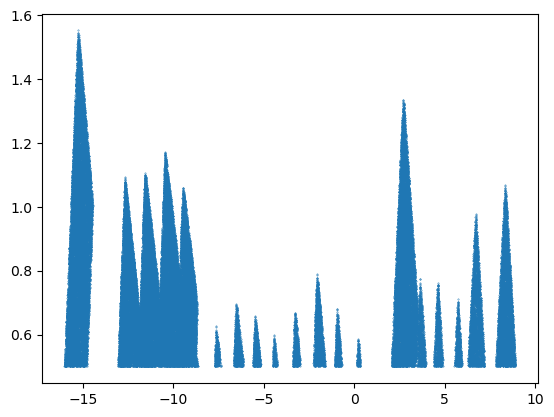

In [464]:

x = all_i19.phi1[all_i19.phi2hat>=bg_start]
y = all_i19.phi2hat[all_i19.phi2hat>=bg_start]
plt.scatter(x,y, s=0.1)

grid_size = 0.1
counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10,grid_size), np.arange(bg_start,1.5,grid_size)])[0].astype(int)

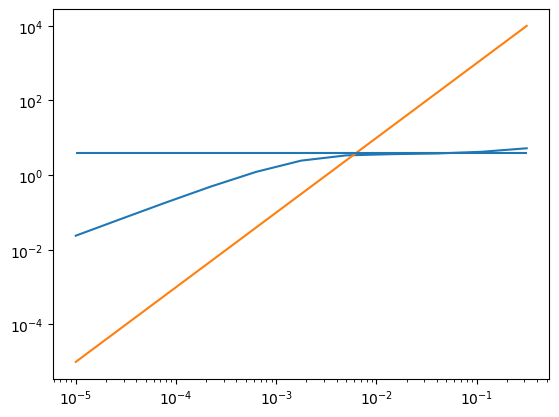

In [465]:
plt.plot(res, areas)

plt.plot(res, len(all_i19.phi1[all_i19.phi2hat>=bg_start])*res**2)
plt.hlines(4, res[0], res[-1])

plt.xscale('log')
plt.yscale('log')

In [475]:
key = 'Pal_5'
bg_start = 0.5
sizex = 0.03
sizey = 0.03

area_all = get_area(sizex, sizey, all=True)
area_above = get_area(sizex, sizey, bg_start=bg_start)
mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
print(len(ds_i19[key].phi1[mask_above])*area_all/area_above)

area_below = get_area(sizex, sizey, bg_start=bg_start, above=False)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
print(len(ds_i19[key].phi1[mask_below])*area_all/area_below)

mask_out = mask_above | mask_below
area_out = area_above + area_below
print(len(ds_i19[key].phi1[mask_out])*area_all/area_out)


10675.089992800575
10932.965083798883
10805.99291031549


mass of a segment = 13238.1 Msun
mass of a segment = 6321.14 Msun
total mass from CFHT = 19559.2 Msun


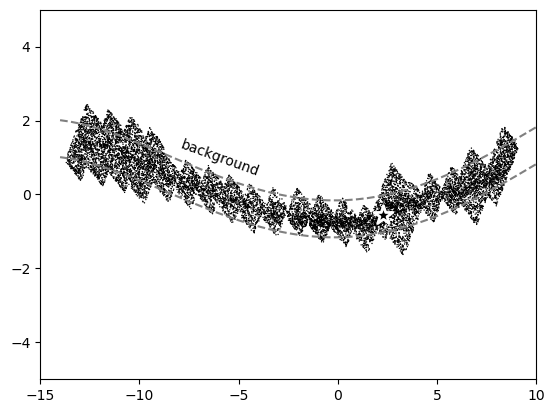

In [486]:
key = 'Pal_5'
mass_func = kroupa
bg_start = 0.5
sizex = 0.03
sizey = 0.03
yaxis = 'phi2'

stream = ds_i19[key]

# # plot mock stars and prog GC
# x = mockstream.phi1
# x_prog = mockstream.prog_phi1
# if yaxis == 'phi2hat':
#     y = mockstream.phi2hat
# elif yaxis == 'phi2':
#     y = mockstream.phi2
# else:
#     raise AttributeError
# plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
plt.scatter(x, y, s=1, ec='none', fc='k')
plt.scatter(x_prog, y_prog, s=200, ec='w', fc='k', marker='*', lw=2)

# plot background boundaries
if yaxis == 'phi2hat':
    plt.hlines([bg_start, -bg_start], -14, 10, color='gray', ls='--')
elif yaxis == 'phi2':
    x = np.linspace(-14, 10, 49)
    y = stream.fit_poly(x)
    plt.plot(x, y+bg_start, c='gray', ls='--')
    plt.plot(x, y-bg_start, c='gray', ls='--')
        
# detect segments
segs = detect_segs(stream)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
dist_mod = 5*(np.log10(dist)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
mask_bg = mask_above | mask_below

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)

# background density
density_bg = np.sum(masses[mask_bg]*weights[mask_bg]) / area_out

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])

    area_seg = get_area(sizex, sizey, all=True, left=seg[0], right=seg[1])
        
    print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])-density_bg*area_seg))
    
    mtot += np.sum(masses[mask]*weights[mask])-density_bg*area_seg

print('total mass from CFHT = %g Msun'%mtot)

plt.xlim(-15,10)
plt.ylim(-5,5)

plt.text(-8, 0.5, 'background', rotation=-20)

plt.show()